# WMH-MedSAM-LoRA — Main paper qualitative figure

Independent Colab notebook derived from `WMH_Qualitative_Segmentation_Figures_FINAL.ipynb`.
Run cells in order after mounting Drive. No training is performed, and no source
notebook is executed/imported at runtime. All definitions from the working
supplementary pipeline are embedded here. The supplementary notebook and its
outputs remain untouched.

**Figure:** three existing supplementary cases × four columns: Input FLAIR,
Ground Truth, U-Net, and the recorded best LoRA configuration (rank 4 or rank 8).
Green is ground truth, orange is prediction; white contours indicate GT in
prediction panels. Dice appears only on prediction panels. Identical existing
insets and full-slice metrics are retained.

## Exactly what changed

| Source section | Main-notebook change |
|---|---|
| 01 Configuration | Append main-output and report-selection settings. Retain PROJECT_ROOT, data/checkpoint/manifest/source paths and all existing options. Route inherited pipeline outputs to `main_figure_v1/pipeline_audit/`. |
| Added 04a | Read and compare recorded rank-4/rank-8 ablation results under one explicit protocol; record source files and checkpoint identity. No metric computation or benchmark logic is changed. |
| Added 05a | Verify all five reproduced cases against the saved supplementary `selected_cases.csv`; select only Small lesion, Multi-lesion and Difficult for display. |
| Added 13a | Audit the selected six predictions and their checkpoint provenance before plotting. |
| 14 Figure generation | Reuse the exact display, overlay and shared-inset helpers; render a 3×4 figure instead of the supplementary layout. Save the requested main PNG/PDF names. |
| 15 Caption | Change caption wording only. Retain every existing configuration/provenance/hash-check statement after the caption. |
| Added 16 | Save the three-case CSV and a main-figure provenance wrapper, preserving the inherited provenance record. |

**Unchanged:** sections 02–13 (artifact audit, data/model loading, preprocessing,
case-generation algorithm, prediction lookup/inference, Dice and other metrics).
The inherited pipeline still processes its five validated cases and four models;
only the main display is reduced to three cases and two models. This preserves
its batch grouping and verification checks instead of introducing another
inference path. The additional audit files remain inside `pipeline_audit/`.

## Rank and case selection

The winner is selected from **already recorded overall test Dice**, using the
same named protocol for both ranks; default `F144_raw_target_batch_mean`, the
source reproduction/ablation's headline protocol. Supported existing reports are
`run_summary.json` (`overall_measured`) or a CSV with `protocol,dice` (and optional
model/mode columns). The existing run directories are derived from the unchanged
checkpoint paths, not guessed by filename elsewhere. If reports cannot be found
unambiguously, set `ABLATION_RESULT_FILES` to your existing reports. No fallback
to validation Dice, per-case scores, synthetic values, or a preferred rank occurs.
Exact score ties select rank 4 because it has fewer adapter parameters.

This is a **post hoc figure-model choice from existing test results**, not a new
independent test-set model-selection result. Per-panel Dice retains the original
binary per-slice calculation; it is distinct from the recorded aggregate metric
used to choose the displayed rank. No thresholds, weights, masks, or scores are
changed to make a model look better.

Cases are fixed by their existing category, without ranking by model performance.
The known supplementary choices give Amsterdam / Utrecht / Amsterdam for Small
lesion / Multi-lesion / Difficult. Singapore cannot be included while preserving
all three categories and those validated slices. The runtime verifies the actual
saved supplementary selection; no new patients or slices are invented.

The figure illustrates LoRA versus U-Net on these examples. **Frozen MedSAM is
not a column in the requested design**; claims about improvement over frozen
MedSAM must be supported by the existing quantitative and supplementary results.
LoRA does not need to win every displayed slice. MedSAM uses GT-derived boxes;
U-Net is image-only, as in the unchanged pipeline.

## Required main outputs

`PROJECT_ROOT/results/qualitative/main_figure_v1/` contains:

- `main_qualitative_figure.png` — 600 dpi
- `main_qualitative_figure.pdf`
- `selected_cases.csv` — three case identities, original reasons and both Dice values
- `provenance.json` — rank-selection evidence, exact cases/predictions, input/output
  hashes and the intact inherited pipeline provenance

All input paths retain their working supplementary values. The results reports
and saved supplementary selection must exist on Drive. They are not included in
this notebook, and no rank winner or new patient figure is claimed before running.
The original handling of legacy predictions with incomplete fingerprints is
preserved and explicitly carried into main-figure provenance.


### 01. Configure paths and selections (no artifact locations assumed)


In [1]:
# ============================================================
# 01. Configuration
# ============================================================

from pathlib import Path


# ============================================================
# Project paths
# ============================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/WMH_MedSAM_Project"
)


# Qualitative output directory
# Syntax-only correction: remove the duplicated Path call; the output path is unchanged.
OUTPUT_DIR = Path(
    "/content/drive/MyDrive/WMH_MedSAM_Project/results/qualitative/final_supplementary_v1"
)



MOUNT_GOOGLE_DRIVE = True



# ============================================================
# Dataset / source paths
# ============================================================

TEST_CSV_PATH = Path(
    "/content/drive/MyDrive/WMH_MedSAM_Project/configs/Copy of original_test.csv"
)


# MedSAM source is cloned in Colab runtime
MEDSAM_SOURCE_DIR = Path(
    "/content/MedSAM"
)


# MedSAM base checkpoint
MEDSAM_BASE_CHECKPOINT = Path(
    "/content/drive/MyDrive/WMH_MedSAM_Project/checkpoints/medsam_vit_b.pth"
)


UNET_ARCH_SOURCE = Path(
    "/content/drive/MyDrive/WMH-MedSAM-LoRA/notebooks/WMH_Benchmark_U-Net_vs_MedSAM.ipynb"
)



# ============================================================
# Experiment checkpoints
# ============================================================

CHECKPOINTS = {

    "unet":
    "/content/drive/MyDrive/WMH_MedSAM_Project/unet_baseline/checkpoints/best_unet_wmh.pth",


    "frozen":
    "/content/drive/MyDrive/WMH_MedSAM_Project/results/ablation/frozen/a100_frozen_run004/checkpoints/best_lora_wmh.pth",


    "lora_r4":
    "/content/drive/MyDrive/WMH_MedSAM_Project/results/ablation/lora_r4/a100_run001/checkpoints/best_lora_wmh.pth",


    "lora_r8":
    "/content/drive/MyDrive/WMH_MedSAM_Project/results/ablation/lora_r8/a100_r8_run002/checkpoints/best_lora_wmh.pth",
}


EXPECTED_CHECKPOINT_SHA256 = {}

    # Visualization colors
PRED_COLOR = (1.0, 0.55, 0.0)   # orange
GT_COLOR   = (0.0, 1.0, 0.3)   # green


# ============================================================
# Prediction discovery
# ============================================================

PREDICTION_MANIFESTS = [
    "/content/drive/MyDrive/WMH_MedSAM_Project/benchmark_runs/unet_vs_medsam_002/configs/medsam_cache_index.csv"
]

PREDICTION_CONTEXT = {}

REQUIRE_VERIFIED_PREDICTIONS = False



# ============================================================
# Path remapping
# ============================================================

PATH_REMAP = []

PATIENT_FILES = {}



# ============================================================
# Model aliases
# ============================================================

MODEL_ALIASES = {

    "U-Net": "unet",
    "UNet": "unet",
    "unet": "unet",

    "Frozen MedSAM": "frozen",
    "frozen": "frozen",

    "LoRA-r4": "lora_r4",
    "lora_r4": "lora_r4",

    "LoRA-r8": "lora_r8",
    "lora_r8": "lora_r8",

    "MedSAM-LoRA": "lora_r4",
}



# ============================================================
# Models included in qualitative figure
# ============================================================

MODELS = [
    "unet",
    "frozen",
    "lora_r4",
    "lora_r8",
]


MODEL_TITLES = [
    "U-Net",
    "Frozen MedSAM",
    "LoRA rank 4",
    "LoRA rank 8",
]



# ============================================================
# Case selection
# ============================================================

MANUAL_CASES = None


CATEGORIES = [
    "Easy",
    "Medium",
    "Difficult",
    "Small lesion",
    "Multi-lesion",
]



# ============================================================
# Dataset expectations
# ============================================================

EXPECTED_PATIENTS = {
    ('Amsterdam','112'),
    ('Amsterdam','116'),
    ('Amsterdam','137'),
    ('Singapore','60'),
    ('Singapore','65'),
    ('Singapore','66'),
    ('Utrecht','21'),
    ('Utrecht','23'),
    ('Utrecht','49'),
}


EXPECTED_SITE_SLICES = {
    "Amsterdam": 249,
    "Singapore": 144,
    "Utrecht": 144,
}



# ============================================================
# Visualization settings
# ============================================================

SEED = 42


SCORE_SIZE = (
    1024,
    1024
)


THRESHOLD = 0.5


DPI = 600


OVERLAY_ALPHA = 0.48


FIGURE_WIDTH_INCHES = 1



# ============================================================
# Figure inset settings
# ============================================================

SHOW_SHARED_INSETS = True


INSET_MIN_SIZE = 20


INSET_PADDING = 5



# ============================================================
# Figure colors / labels
# ============================================================

MASK_COLOR = "#F0A202"

# ADDED for the main figure only. Original input/checkpoint options above are unchanged.
SUPPLEMENTARY_OUTPUT_DIR = OUTPUT_DIR
MAIN_OUTPUT_DIR = PROJECT_ROOT / 'results/qualitative/main_figure_v1'
OUTPUT_DIR = MAIN_OUTPUT_DIR / 'pipeline_audit'
SUPPLEMENTARY_CASES_CSV = SUPPLEMENTARY_OUTPUT_DIR / 'selected_cases.csv'
MAIN_CATEGORIES = ['Small lesion', 'Multi-lesion', 'Difficult']
# Optional explicit paths to EXISTING rank reports; no scores are entered here.
ABLATION_RESULT_FILES = {'lora_r4': None, 'lora_r8': None}
RANKING_PROTOCOL = 'F144_raw_target_batch_mean'

SOURCE_SUPPLEMENTARY_SHA256 = '8701b9dea61dfa755db288e85e3115461a0e57a096e758882034b5ef086d75ac'


### 02. Audit the project before inference or figure generation


In [2]:
# ============================================================
# 02. Environment, output directory, utilities and artifact audit
# ============================================================

import os
import json
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")


# ============================================================
# Google Drive mount
# ============================================================

if MOUNT_GOOGLE_DRIVE:
    from google.colab import drive

    try:
        drive.mount("/content/drive")
    except Exception as e:
        print("Drive mount status:", e)


# ============================================================
# Output directory
# ============================================================

OUTPUT_DIR = (
    Path(OUTPUT_DIR).expanduser().resolve()
    if OUTPUT_DIR
    else PROJECT_ROOT / "results/qualitative/run_001"
)


# Safe repeated execution
if OUTPUT_DIR.exists():

    print(
        f"Using existing output directory:\n{OUTPUT_DIR}"
    )

else:

    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True
    )

    print(
        f"Created output directory:\n{OUTPUT_DIR}"
    )


# ============================================================
# Utility functions
# ============================================================

def sha256_file(path, chunk_size=1024 * 1024):

    path = Path(path)

    h = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(chunk_size),
            b""
        ):
            h.update(chunk)

    return h.hexdigest()



def track(path):

    return str(Path(path).resolve())



def save_json(obj, filename):

    out = OUTPUT_DIR / filename

    with open(out, "w") as f:

        json.dump(
            obj,
            f,
            indent=2,
            default=str
        )

    return out



def choose_unique(paths, description, explicit=None):

    paths = [
        Path(p)
        for p in paths
    ]

    if explicit is not None:

        explicit = Path(explicit)

        if explicit not in paths:

            raise ValueError(
                f"Explicit {description} not found:\n{explicit}"
            )

        return explicit


    if len(paths) == 0:

        raise FileNotFoundError(
            f"No {description} found"
        )


    if len(paths) == 1:

        return paths[0]


    # accept identical duplicates
    hashes = {}

    for p in paths:

        hashes.setdefault(
            sha256_file(p),
            []
        ).append(p)


    if len(hashes) == 1:

        return paths[0]


    raise ValueError(
        f"Ambiguous {description}; "
        "choose explicitly in Cell 01:\n"
        +
        "\n".join(map(str, paths))
    )


# ============================================================
# Device
# ============================================================

import torch

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Device:",
    device
)


# ============================================================
# Artifact inventory
# ============================================================

inventory = []

search_roots = [
    PROJECT_ROOT
]


for root in search_roots:

    if not root.exists():
        continue

    for p in root.rglob("*"):

        if not p.is_file():
            continue


        suffix = "".join(
            p.suffixes
        ).lower()


        category = None


        if suffix in [
            ".pth",
            ".pt",
            ".ckpt"
        ]:

            category = "checkpoint"


        elif suffix in [
            ".nii",
            ".nii.gz"
        ]:

            category = "nifti_image_or_mask"


        elif suffix in [
            ".npy",
            ".npz"
        ]:

            category = "prediction_or_array"


        elif suffix == ".csv":

            category = "csv"



        if category:

            inventory.append(
                {
                    "path": str(p),

                    # New schema
                    "category": category,

                    # Backward compatibility with Astra cells
                    "kind": category,

                    "size_mb": round(
                        p.stat().st_size / 1024**2,
                        3
                    )
                }
            )


# ============================================================
# Inventory summary
# ============================================================

inventory_df = pd.DataFrame(
    inventory
)


if len(inventory_df):

    display(
        inventory_df.head(20)
    )

    print(
        "\nArtifact counts:"
    )

    print(
        inventory_df["category"]
        .value_counts()
    )

else:

    print(
        "No artifacts found."
    )


# ============================================================
# Save audit metadata
# ============================================================

save_json(
    {
        "project_root": str(PROJECT_ROOT),
        "output_dir": str(OUTPUT_DIR),
        "device": device,
        "artifact_count": len(inventory)
    },
    "audit_environment.json"
)


print(
    "\nInventory ready:",
    len(inventory),
    "artifacts"
)

Mounted at /content/drive
Created output directory:
/content/drive/MyDrive/WMH_MedSAM_Project/results/qualitative/main_figure_v1/pipeline_audit
Device: cuda


,path,category,kind,size_mb
0,/content/drive/MyDrive/WMH_MedSAM_Project/mani...,csv,csv,0.013
1,/content/drive/MyDrive/WMH_MedSAM_Project/mani...,csv,csv,0.009
2,/content/drive/MyDrive/WMH_MedSAM_Project/mani...,csv,csv,0.002
3,/content/drive/MyDrive/WMH_MedSAM_Project/mani...,csv,csv,0.002
4,/content/drive/MyDrive/WMH_MedSAM_Project/chec...,checkpoint,checkpoint,357.675
5,/content/drive/MyDrive/WMH_MedSAM_Project/eval...,csv,csv,0.003
6,/content/drive/MyDrive/WMH_MedSAM_Project/eval...,csv,csv,0.000
7,/content/drive/MyDrive/WMH_MedSAM_Project/eval...,csv,csv,0.000
8,/content/drive/MyDrive/WMH_MedSAM_Project/logs...,csv,csv,0.002
9,/content/drive/MyDrive/WMH_MedSAM_Project/unet...,csv,csv,0.003



Artifact counts:
category
prediction_or_array    1681
csv                     123
nifti_image_or_mask     120
checkpoint                7
Name: count, dtype: int64

Inventory ready: 1931 artifacts


### 03. Imports, deterministic setup and explicit path resolution


In [3]:
import ast, gc, platform, random, subprocess
import numpy as np
import pandas as pd
import nibabel as nib
import cv2
from scipy import ndimage
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch, Rectangle
from matplotlib.lines import Line2D
from IPython.display import display
import torch
import torch.nn as nn
import torch.nn.functional as F
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark=False
torch.backends.cudnn.deterministic=True
torch.use_deterministic_algorithms(True)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tracked_inputs={}
def track(path):
    p=Path(path).resolve(); tracked_inputs[str(p)]=sha256_file(p); return p

def resolve_path(value, base=PROJECT_ROOT):
    p=Path(str(value)).expanduser()
    candidates=[p] if p.is_absolute() else [Path(base)/p,PROJECT_ROOT/p]
    for old,new in PATH_REMAP:
        try: relative=p.relative_to(Path(old))
        except ValueError:continue
        candidates.append(Path(new)/relative)
    found=sorted({c.resolve() for c in candidates if c.is_file()})
    if len(found)!=1:raise FileNotFoundError(f'Expected one file for {value}; found {found}. Configure PATH_REMAP or explicit paths.')
    return found[0]

def choose_unique(paths, description, explicit=None):
    if explicit is not None:return resolve_path(explicit)
    paths=sorted(set(Path(p).resolve() for p in paths))
    if not paths:raise FileNotFoundError(f'No {description} located. Configure its path in cell 01.')
    # Byte-identical copies may be selected deterministically; distinct runs may not.
    groups={}
    for p in paths:groups.setdefault(sha256_file(p),[]).append(p)
    if len(groups)!=1:
        raise ValueError(f'Ambiguous {description}; choose explicitly in cell 01:\n'+ '\n'.join(map(str,paths)))
    return paths[0]
print('Device:',device,'; all files will be resolved from audited paths or explicit overrides.')


Device: cuda ; all files will be resolved from audited paths or explicit overrides.


### 04. Verify the exact test split and resolve image/mask pairs


In [4]:
# ============================================================
# 04. Verify the exact test split and resolve image/mask pairs
# ============================================================

split_candidates=[]

for entry in inventory:
    p=Path(entry['path'])
    if p.suffix.lower()!='.csv' or 'test' not in p.stem.lower():
        continue

    try:
        frame=pd.read_csv(p)
    except (ValueError,pd.errors.ParserError,UnicodeError):
        continue

    required={'site','patient_id','image_path','mask_path'}

    if required.issubset(frame) and len(frame)==9:
        keys=set(zip(frame.site.astype(str),frame.patient_id.astype(str)))
        if keys==EXPECTED_PATIENTS:
            split_candidates.append(p)


TEST_CSV_PATH=choose_unique(
    split_candidates,
    'original test CSV',
    TEST_CSV_PATH
)

track(TEST_CSV_PATH)

test_df=pd.read_csv(TEST_CSV_PATH)

assert {'site','patient_id','image_path','mask_path'}.issubset(test_df)

test_df['patient_id']=test_df['patient_id'].astype(str)

assert len(test_df)==9 and not test_df.duplicated(
    ['site','patient_id']
).any()

assert set(zip(test_df.site,test_df.patient_id))==EXPECTED_PATIENTS

(OUTPUT_DIR/'original_test.csv').write_bytes(
    TEST_CSV_PATH.read_bytes()
)


# CSV paths first. Only if stale, use unique raw WMH file matches in audit.
resolved=[]

for row in test_df.itertuples(index=False):

    key=(row.site,row.patient_id)

    if key in PATIENT_FILES:

        image_path,mask_path=[
            resolve_path(v)
            for v in PATIENT_FILES[key]
        ]

    else:

        try:
            image_path=resolve_path(
                row.image_path,
                TEST_CSV_PATH.parent
            )

            mask_path=resolve_path(
                row.mask_path,
                TEST_CSV_PATH.parent
            )

        except FileNotFoundError:

            masks=[
                Path(e['path'])
                for e in inventory
                if Path(e['path']).name in {
                    'wmh.nii',
                    'wmh.nii.gz'
                }
                and Path(e['path']).parent.name==row.patient_id
                and row.site in Path(e['path']).parts
            ]

            if len(masks)!=1:
                raise ValueError(
                    f'Cannot uniquely resolve {key}. Set PATIENT_FILES.'
                )

            mask_path=masks[0]

            images=[
                p
                for p in [
                    mask_path.parent/'pre/FLAIR.nii',
                    mask_path.parent/'pre/FLAIR.nii.gz'
                ]
                if p.is_file()
            ]

            if len(images)!=1:
                raise ValueError(
                    f'Cannot uniquely resolve FLAIR for {key}. '
                    'Set PATIENT_FILES.'
                )

            image_path=images[0]


    image_nii,mask_nii = (
        nib.load(image_path),
        nib.load(mask_path)
    )


    # --------------------------------------------------------
    # Geometry validation
    # Allow negligible floating-point affine differences
    # but reject true image-mask mismatch.
    # --------------------------------------------------------

    assert (
        image_nii.ndim==3
        and image_nii.shape==mask_nii.shape
    ), key


    if not np.allclose(
        image_nii.affine,
        mask_nii.affine,
        atol=1e-4
    ):
        raise ValueError(
            f'Image/mask geometry mismatch: {key}'
        )


    resolved.append(
        {
            'site':row.site,
            'patient_id':row.patient_id,
            'image_path':str(track(image_path)),
            'mask_path':str(track(mask_path)),
            'depth':image_nii.shape[2]
        }
    )


resolved_df=pd.DataFrame(resolved)


assert (
    resolved_df.groupby('site').depth.sum().to_dict()
    ==
    EXPECTED_SITE_SLICES
)

assert resolved_df.depth.sum()==537


resolved_df.to_csv(
    OUTPUT_DIR/'resolved_test_files.csv',
    index=False
)


display(resolved_df)

,site,patient_id,image_path,mask_path,depth
0,Singapore,60,/content/drive/MyDrive/WMH_MedSAM_Project/data...,/content/drive/MyDrive/WMH_MedSAM_Project/data...,48
1,Amsterdam,112,/content/drive/MyDrive/WMH_MedSAM_Project/data...,/content/drive/MyDrive/WMH_MedSAM_Project/data...,83
2,Utrecht,49,/content/drive/MyDrive/WMH_MedSAM_Project/data...,/content/drive/MyDrive/WMH_MedSAM_Project/data...,48
3,Utrecht,23,/content/drive/MyDrive/WMH_MedSAM_Project/data...,/content/drive/MyDrive/WMH_MedSAM_Project/data...,48
4,Amsterdam,137,/content/drive/MyDrive/WMH_MedSAM_Project/data...,/content/drive/MyDrive/WMH_MedSAM_Project/data...,83
5,Singapore,66,/content/drive/MyDrive/WMH_MedSAM_Project/data...,/content/drive/MyDrive/WMH_MedSAM_Project/data...,48
6,Singapore,65,/content/drive/MyDrive/WMH_MedSAM_Project/data...,/content/drive/MyDrive/WMH_MedSAM_Project/data...,48
7,Utrecht,21,/content/drive/MyDrive/WMH_MedSAM_Project/data...,/content/drive/MyDrive/WMH_MedSAM_Project/data...,48
8,Amsterdam,116,/content/drive/MyDrive/WMH_MedSAM_Project/data...,/content/drive/MyDrive/WMH_MedSAM_Project/data...,83


### 04a. Added — audit existing ablation reports and select the displayed LoRA rank


In [5]:
# ADDED: choose the displayed rank from recorded ablation results, never case scores.
# This reads existing reports and does not recompute or modify the benchmark.
def read_rank_report(path, mode):
    path = Path(path)
    metadata = {}
    if path.suffix.lower() == '.json':
        metadata = json.loads(path.read_text())
        if not isinstance(metadata, dict) or not isinstance(metadata.get('overall_measured'), list):
            raise ValueError('Expected a run summary with overall_measured records.')
        frame = pd.DataFrame(metadata['overall_measured'])
    elif path.suffix.lower() == '.csv':
        frame = pd.read_csv(path)
    else:
        raise ValueError('Use an existing JSON run summary or CSV aggregate result table.')
    if not {'protocol', 'dice'}.issubset(frame.columns):
        raise ValueError('Result table needs protocol and dice columns; do not guess its metric semantics.')
    for column in ['model', 'ablation_mode', 'mode']:
        if column in frame:
            frame = frame[frame[column].map(lambda v: MODEL_ALIASES.get(str(v), str(v))) == mode]
    frame = frame[frame['protocol'] == RANKING_PROTOCOL]
    if len(frame) != 1:
        raise ValueError(f'Expected exactly one {mode}/{RANKING_PROTOCOL} row, found {len(frame)}.')
    row = frame.iloc[0]
    score = float(row['dice'])
    if not np.isfinite(score):
        raise ValueError('Recorded Dice is not finite.')
    # Raw-label historical Dice is intentionally not clipped or rewritten.
    if 'batches' in row and pd.notna(row['batches']):
        assert int(row['batches']) == 269, 'Not the same full-test batch protocol'
    if 'slices' in row and pd.notna(row['slices']):
        assert int(row['slices']) == 537, 'Not the same test cohort'
    declared = metadata.get('ablation_mode')
    if declared is not None:
        assert declared == mode, 'Result report belongs to a different ablation'
    slices = metadata.get('verification', {}).get('slices')
    if slices is not None:
        assert list(slices) == [2506, 537, 537]
    checkpoint_hash = metadata.get('evaluation_checkpoint_sha256') or metadata.get('checkpoint_sha256')
    if checkpoint_hash is None and 'checkpoint_sha256' in row and pd.notna(row['checkpoint_sha256']):
        checkpoint_hash = str(row['checkpoint_sha256'])
    return {'model': mode, 'protocol': RANKING_PROTOCOL, 'dice': score,
            'report_path': str(path.resolve()), 'report_metadata': metadata,
            'reported_checkpoint_sha256': checkpoint_hash}

rank_evidence = []
for mode in ['lora_r4', 'lora_r8']:
    checkpoint_path = track(resolve_path(CHECKPOINTS[mode]))
    # Run directories follow the already configured .../checkpoints/<file> paths.
    run_dir = checkpoint_path.parent.parent
    explicit = ABLATION_RESULT_FILES[mode]
    if explicit is not None:
        candidates = [resolve_path(explicit)]
    else:
        # Prefer existing summaries, which contain checkpoint identity as well as scores.
        candidates = sorted(run_dir.rglob('run_summary.json'))
        if not candidates:
            candidates = sorted(run_dir.rglob('overall_historical_protocols.csv'))
    valid = []
    report_errors = []
    for path in candidates:
        try:
            evidence = read_rank_report(path, mode)
            if evidence['reported_checkpoint_sha256']:
                assert evidence['reported_checkpoint_sha256'] == tracked_inputs[str(checkpoint_path)], 'Report/checkpoint hash mismatch'
            valid.append((path, evidence))
        except Exception as error:
            report_errors.append(f'{path}: {error}')
    if not valid:
        raise ValueError(f'No compatible existing report for {mode}. Set ABLATION_RESULT_FILES to its saved report.\n' + '\n'.join(report_errors))
    report_path = choose_unique([path for path, _ in valid], f'{mode} ablation result report')
    evidence = next(item for path, item in valid if path.resolve() == report_path.resolve())
    track(report_path)
    evidence.update(report_sha256=tracked_inputs[str(report_path.resolve())],
                    configured_checkpoint_path=str(checkpoint_path),
                    configured_checkpoint_sha256=tracked_inputs[str(checkpoint_path)],
                    checkpoint_association='report SHA256 matched' if evidence['reported_checkpoint_sha256'] else
                        'configured run/path association; report lacks checkpoint fingerprint')
    # Use existing split records when present; absence is recorded, never fabricated.
    split_record = run_dir / 'configs/split_sha256.json'
    evidence['split_record_path'] = None
    if split_record.is_file():
        split_record = track(split_record)
        split_hashes = json.loads(split_record.read_text())
        assert split_hashes['test'] == tracked_inputs[str(TEST_CSV_PATH)], 'Ablation uses a different test CSV'
        evidence['split_record_path'] = str(split_record)
    rank_evidence.append(evidence)

rank_table = pd.DataFrame([{k: r[k] for k in ['model', 'protocol', 'dice', 'report_path', 'checkpoint_association']}
                          for r in rank_evidence])
assert rank_table['protocol'].nunique() == 1
# max() over this explicit order keeps rank 4 only on an exact recorded-score tie.
BEST_LORA_MODEL = max(['lora_r4', 'lora_r8'], key=lambda mode: next(r['dice'] for r in rank_evidence if r['model'] == mode))
BEST_LORA_RANK = {'lora_r4': 4, 'lora_r8': 8}[BEST_LORA_MODEL]
MAIN_MODELS = ['unet', BEST_LORA_MODEL]
display(rank_table)
print('Displayed configuration:', BEST_LORA_MODEL, '; criterion:', RANKING_PROTOCOL, 'recorded overall Dice')


,model,protocol,dice,report_path,checkpoint_association
0,lora_r4,F144_raw_target_batch_mean,0.873912,/content/drive/MyDrive/WMH_MedSAM_Project/resu...,report SHA256 matched
1,lora_r8,F144_raw_target_batch_mean,0.876796,/content/drive/MyDrive/WMH_MedSAM_Project/resu...,report SHA256 matched


Displayed configuration: lora_r8 ; criterion: F144_raw_target_batch_mean recorded overall Dice


### 05. Compute ground-truth descriptors and select five cases before predictions


In [6]:
def describe_mask(binary):
    labels,n=ndimage.label(binary,structure=np.ones((3,3),dtype=np.uint8))
    areas=np.bincount(labels.ravel())[1:]
    return {'lesion_pixels_native':int(binary.sum()),'components_8connected':int(n),
            'largest_component_pixels':int(areas.max()) if n else 0}
cohort=[]
for row in resolved_df.itertuples(index=False):
    mask=nib.load(row.mask_path).get_fdata()
    assert np.isfinite(mask).all()
    for z in range(mask.shape[2]):
        cohort.append({'site':row.site,'patient_id':row.patient_id,'slice_id':z,
                       **describe_mask(mask[:,:,z]>0)})
cohort_df=pd.DataFrame(cohort)
assert len(cohort_df)==537 and (cohort_df.lesion_pixels_native>0).sum()==232
cohort_df.to_csv(OUTPUT_DIR/'cohort_morphology.csv',index=False)
KEYS=['site','patient_id','slice_id']
positive=cohort_df[cohort_df.lesion_pixels_native>0].copy().sort_values(KEYS)
assert len(positive)>=5
positive['burden_percentile']=positive.lesion_pixels_native.rank(method='average',pct=True)
positive['fragmentation_percentile']=positive.components_8connected.rank(method='average',pct=True)
positive['morphology_difficulty']=positive.fragmentation_percentile-positive.burden_percentile
positive['median_distance']=(positive.burden_percentile-.5).abs()+(positive.fragmentation_percentile-.5).abs()

def select_cases(positive, manual=None):
    chosen=[];used=set()
    if manual is not None:
        assert len(manual)==5 and {r['category'] for r in manual}==set(CATEGORIES)
        for requested in manual:
            key=(str(requested['site']),str(requested['patient_id']),int(requested['slice_id']))
            assert key not in used and requested.get('reason'), 'Unique cases and manual reasons required'
            matches=positive[(positive.site==key[0])&(positive.patient_id==key[1])&(positive.slice_id==key[2])]
            assert len(matches)==1,f'Manual case not a positive test slice: {key}'
            chosen.append({**matches.iloc[0].to_dict(),'category':requested['category'],
                           'selection_method':'manual','selection_reason':requested['reason']});used.add(key)
    else:
        rules=[('Small lesion',['lesion_pixels_native'],[True],'Minimum positive native-mask area'),
               ('Multi-lesion',['components_8connected','lesion_pixels_native'],[False,False],'Maximum 8-connected component count'),
               ('Easy',['morphology_difficulty','lesion_pixels_native'],[True,False],'Low fragmentation / high burden proxy'),
               ('Difficult',['morphology_difficulty','lesion_pixels_native'],[False,True],'High fragmentation / low burden proxy'),
               ('Medium',['median_distance'],[True],'Closest to median burden and fragmentation')]
        for category,by,ascending,reason in rules:
            available=positive[[tuple(r) not in used for r in positive[KEYS].itertuples(index=False,name=None)]]
            row=available.sort_values(by+KEYS,ascending=ascending+[True]*3,kind='stable').iloc[0]
            if category=='Multi-lesion' and row.components_8connected<2:
                raise ValueError('No genuine multi-component case found; do not mislabel one.')
            used.add(tuple(row[k] for k in KEYS))
            chosen.append({**row.to_dict(),'category':category,'selection_method':'GT-only deterministic',
                           'selection_reason':reason})
    return pd.DataFrame(chosen).set_index('category').loc[CATEGORIES].reset_index()
selected=select_cases(positive,MANUAL_CASES)
assert not selected.duplicated(KEYS).any()
selected.to_csv(OUTPUT_DIR/'selected_cases.csv',index=False)
display(selected[['category']+KEYS+['lesion_pixels_native','components_8connected','selection_reason']])


,category,site,patient_id,slice_id,lesion_pixels_native,components_8connected,selection_reason
0,Easy,Singapore,65,15,864,1,Low fragmentation / high burden proxy
1,Medium,Utrecht,21,17,80,5,Closest to median burden and fragmentation
2,Difficult,Amsterdam,137,53,62,13,High fragmentation / low burden proxy
3,Small lesion,Amsterdam,112,41,1,1,Minimum positive native-mask area
4,Multi-lesion,Utrecht,49,26,1002,34,Maximum 8-connected component count


### 05a. Added — verify the supplementary case list and select its three-case subset


In [7]:
# ADDED: verify membership in the completed supplementary run before taking a subset.
supplementary_case_path = track(resolve_path(SUPPLEMENTARY_CASES_CSV))
supplementary_saved_cases = pd.read_csv(supplementary_case_path, dtype={'patient_id': str})
required_case_columns = ['category'] + KEYS
assert set(required_case_columns).issubset(supplementary_saved_cases.columns)
assert len(supplementary_saved_cases) == 5
assert not supplementary_saved_cases.duplicated(KEYS).any()
assert not supplementary_saved_cases['category'].duplicated().any()
expected_case_rows = set(supplementary_saved_cases[required_case_columns].itertuples(index=False, name=None))
current_case_rows = set(selected[required_case_columns].itertuples(index=False, name=None))
assert current_case_rows == expected_case_rows, 'Current selection differs from the validated supplementary cases; do not substitute new cases.'
main_selected = selected.set_index('category').loc[MAIN_CATEGORIES].reset_index().copy()
assert len(main_selected) == 3 and not main_selected.duplicated(KEYS).any()
assert set(main_selected[required_case_columns].itertuples(index=False, name=None)).issubset(expected_case_rows)
print('Main rows are an unchanged subset of the validated supplementary cases:')
display(main_selected[['category'] + KEYS + ['selection_reason']])
print('Sites represented:', ', '.join(main_selected.site.drop_duplicates()))
print('Category fidelity takes priority over substituting cases to force three-site coverage.')


Main rows are an unchanged subset of the validated supplementary cases:


,category,site,patient_id,slice_id,selection_reason
0,Small lesion,Amsterdam,112,41,Minimum positive native-mask area
1,Multi-lesion,Utrecht,49,26,Maximum 8-connected component count
2,Difficult,Amsterdam,137,53,High fragmentation / low burden proxy


Sites represented: Amsterdam, Utrecht
Category fidelity takes priority over substituting cases to force three-site coverage.


### 06. Build exact model inputs and common figure targets for selected cases


In [8]:
cases={}
def array_hash(a):
    a=np.ascontiguousarray(a)
    return hashlib.sha256(str((a.shape,a.dtype.str)).encode()+a.tobytes()).hexdigest()
for row in selected.itertuples(index=False):
    patient=resolved_df[(resolved_df.site==row.site)&(resolved_df.patient_id==row.patient_id)].iloc[0]
    image=nib.load(patient.image_path).get_fdata()[:,:,row.slice_id]
    mask=nib.load(patient.mask_path).get_fdata()[:,:,row.slice_id]
    assert np.isfinite(image).all() and np.isfinite(mask).all()
    normalized=(image-image.min())/(image.max()-image.min()+1e-8)
    rgb=cv2.resize(np.stack([normalized]*3,axis=-1),SCORE_SIZE,interpolation=cv2.INTER_LINEAR)
    raw_target=cv2.resize(mask.astype(np.float32),SCORE_SIZE,interpolation=cv2.INTER_NEAREST)
    binary=raw_target>0
    ys,xs=np.where(binary)
    box=np.array([xs.min(),ys.min(),xs.max(),ys.max()] if len(xs) else [0,0,0,0],dtype=np.float32)
    unet_image=cv2.resize(normalized,(256,256),interpolation=cv2.INTER_LINEAR)
    key=(row.site,row.patient_id,int(row.slice_id))
    cases[key]={'image':rgb[:,:,0].astype(np.float32),'target':binary,'raw_target':raw_target,
                'sam_input':torch.tensor(rgb.transpose(2,0,1),dtype=torch.float32),
                'unet_input':torch.tensor(unet_image[None],dtype=torch.float32),'box':torch.tensor(box),
                'image_sha256':tracked_inputs[patient.image_path],
                'mask_sha256':tracked_inputs[patient.mask_path],
                'target_sha256':array_hash(binary.astype(np.uint8))}
    assert cases[key]['sam_input'].shape==(3,1024,1024)
    assert cases[key]['unet_input'].shape==(1,256,256)
print('Prepared five shared targets and original model-specific inputs. No inference yet.')


Prepared five shared targets and original model-specific inputs. No inference yet.


### 07. Locate indexed predictions and report what still needs inference


In [9]:
if PREDICTION_MANIFESTS is None:
    manifests=[Path(e['path']) for e in inventory if Path(e['path']).name.endswith('_cache_index.csv')
               or Path(e['path']).name in {'prediction_manifest.csv','selected_prediction_manifest.csv'}]
else:
    manifests=[resolve_path(p) for p in PREDICTION_MANIFESTS]
prediction_candidates={}; contexts={}; ignored=[]
for manifest in sorted(set(manifests)):
    frame=pd.read_csv(manifest,dtype={'patient_id':str}).fillna('')
    if not {'site','patient_id','slice_id','path'}.issubset(frame):
        ignored.append(str(manifest));continue
    context=dict(PREDICTION_CONTEXT.get(str(manifest.resolve()),{}))
    sidecar=manifest.with_suffix('.json')
    if sidecar.is_file():
        context={**json.loads(track(sidecar).read_text()),**context}
    contexts[str(manifest)]=context
    track(manifest)
    for row in frame.to_dict('records'):
        model=MODEL_ALIASES.get(row.get('model') or context.get('model'))
        if model is None:raise ValueError(f'Unmapped model in {manifest}: {row.get("model")}; configure MODEL_ALIASES.')
        key=(str(row['site']),str(row['patient_id']),int(row['slice_id']))
        if key not in cases:continue
        record={**row,'model':model,'path':str(resolve_path(row['path'],manifest.parent)),
                'manifest':str(manifest),'context':context}
        prediction_candidates.setdefault((model,key),[]).append(record)
for pair,records in prediction_candidates.items():
    if len(records)>1:
        raise ValueError(f'Multiple predictions for {pair}: {[r["manifest"] for r in records]}. Select intended PREDICTION_MANIFESTS.')
missing={model:[key for key in cases if (model,key) not in prediction_candidates] for model in MODELS}
display(pd.DataFrame([{'model':m,'saved_selected_predictions':5-len(missing[m]),
                       'selected_cases_requiring_inference':len(missing[m])} for m in MODELS]))
print('Ignored incompatible CSV schemas:',ignored)
# Unindexed arrays are listed in artifact_inventory.csv but never mapped by a guessed order.


,model,saved_selected_predictions,selected_cases_requiring_inference
0,unet,0,5
1,frozen,0,5
2,lora_r4,5,0
3,lora_r8,0,5


Ignored incompatible CSV schemas: []


### 08. Shared prediction loading, geometry checks and metrics


In [10]:
def binary_from_logits(array):
    a=np.asarray(array)
    assert a.ndim==2 and np.isfinite(a).all()
    assert a.shape in {(256,256),(1024,1024)},f'Unsupported logits grid: {a.shape}'
    t=torch.from_numpy(np.ascontiguousarray(a)).to(device)[None,None]
    if not t.is_floating_point():raise ValueError('Logits must be floating point.')
    with torch.no_grad():
        if t.shape[-2:]!=SCORE_SIZE:
            t=F.interpolate(t,size=SCORE_SIZE,mode='bilinear',align_corners=False)
        result=(torch.sigmoid(t)>THRESHOLD)[0,0].cpu().numpy()
    return result

def binary_metrics(pred,target):
    pred=np.asarray(pred,dtype=bool);target=np.asarray(target,dtype=bool)
    assert pred.shape==target.shape
    tp=int(np.count_nonzero(pred&target));fp=int(np.count_nonzero(pred&~target));fn=int(np.count_nonzero(~pred&target))
    eps=1e-7
    return {'dice':(2*tp+eps)/(2*tp+fp+fn+eps),'iou':(tp+eps)/(tp+fp+fn+eps),
            'sensitivity':(tp+eps)/(tp+fn+eps),'precision':(tp+eps)/(tp+fp+eps),'tp':tp,'fp':fp,'fn':fn}

def load_saved_prediction(record,key):
    path=track(record['path'])
    if record.get('sha256'):assert tracked_inputs[str(path)]==record['sha256'],'Prediction file hash mismatch'
    kind=record.get('kind','')
    if path.suffix=='.npz':
        with np.load(path,allow_pickle=False) as data:
            array_key=record.get('array_key')
            if not array_key:
                recognized=set(data.files)&{'logits','probabilities','mask'}
                if len(recognized)!=1:raise ValueError(f'Specify array_key/kind for {path}: {data.files}')
                array_key=next(iter(recognized))
            if not kind and array_key in {'logits','probabilities','mask'}:kind=array_key
            array=data[array_key].copy()
    elif path.suffix=='.npy':
        array=np.load(path,allow_pickle=False)
    else:raise ValueError(f'Unsupported prediction format: {path}; export an indexed numeric array.')
    assert array.ndim==2,f'Expected an explicitly indexed 2-D array, got {array.shape}'
    assert np.isfinite(array).all()
    if record.get('height'):assert array.shape[0]==int(record['height'])
    if record.get('width'):assert array.shape[1]==int(record['width'])
    if record.get('dtype'):assert str(array.dtype)==record['dtype']
    if kind=='logits':pred=binary_from_logits(array)
    elif kind=='probabilities':
        assert array.shape==SCORE_SIZE and np.all((array>=0)&(array<=1))
        pred=array>THRESHOLD
    elif kind=='mask':
        assert array.shape==SCORE_SIZE and set(np.unique(array)).issubset({0,1,False,True})
        pred=array.astype(bool)
    else:raise ValueError(f'Explicit kind=logits/probabilities/mask required: {path}')
    context=record['context'];case=cases[key]
    source_cp=record.get('checkpoint_sha256') or context.get('checkpoint_sha256')
    csv_hash=record.get('test_csv_sha256') or context.get('test_csv_sha256')
    input_hashes=context.get('input_sha256',{})
    image_hash=record.get('image_sha256') or input_hashes.get(f'{key[0]}/{key[1]}/image')
    mask_hash=record.get('mask_sha256') or input_hashes.get(f'{key[0]}/{key[1]}/mask')
    target_hash=record.get('target_sha256')
    if csv_hash:assert csv_hash==tracked_inputs[str(TEST_CSV_PATH)]
    if image_hash:assert image_hash==case['image_sha256']
    if mask_hash:assert mask_hash==case['mask_sha256']
    if target_hash:assert target_hash==case['target_sha256']
    expected_cp=EXPECTED_CHECKPOINT_SHA256.get(record['model'])
    if expected_cp:assert source_cp==expected_cp,'Saved prediction checkpoint differs from expected'
    verified=bool(source_cp and csv_hash and image_hash and mask_hash)
    if REQUIRE_VERIFIED_PREDICTIONS and not verified:
        raise ValueError(f'Incomplete checkpoint/input provenance for {path}; supply verified context or use inference.')
    provenance={'source_type':'saved_prediction','source_path':str(path),
                'source_sha256':tracked_inputs[str(path)],'kind':kind,'manifest':record['manifest'],
                'checkpoint_sha256':source_cp or '',
                'provenance_status':'supplied fingerprints matched' if verified else 'legacy provenance unverified'}
    return pred,provenance
predictions={};prediction_info={}
for pair,records in prediction_candidates.items():
    predictions[pair],prediction_info[pair]=load_saved_prediction(records[0],pair[1])
# A model's selected cases must not silently mix different checkpoint runs.
for model in MODELS:
    records=[v for (m,k),v in prediction_info.items() if m==model]
    known={r['checkpoint_sha256'] for r in records if r['checkpoint_sha256']}
    if len(known)>1:raise ValueError(f'Different checkpoint fingerprints found for {model}. Select one run.')
    if records and missing[model] and any(not r['checkpoint_sha256'] for r in records):
        raise ValueError(f'{model} has partial legacy predictions with unknown checkpoint identity. Supply PREDICTION_CONTEXT or set PREDICTION_MANIFESTS=[] to infer all selected cases from one checkpoint.')
assert binary_metrics(np.zeros((2,2),bool),np.zeros((2,2),bool))['dice']==1
assert binary_metrics(np.ones((2,2),bool),np.zeros((2,2),bool))['dice']<1e-6
print('Validated and loaded',len(predictions),'saved predictions. No scores used to select cases.')


Validated and loaded 5 saved predictions. No scores used to select cases.


### 09. Inspect checkpoint contents only for missing predictions


In [11]:
def unwrap_state(checkpoint):
    if not isinstance(checkpoint,dict):raise ValueError('Expected a tensor state dictionary or full model_state_dict checkpoint.')
    state=checkpoint.get('model_state_dict',checkpoint)
    if not isinstance(state,dict) or not state or not all(isinstance(v,torch.Tensor) for v in state.values()):
        raise ValueError('Unsupported checkpoint container; provide a model_state_dict checkpoint.')
    return state

def classify_state(state):
    if any(k.startswith('image_encoder.') for k in state):
        a=[v for k,v in state.items() if k.endswith('.lora_A.weight')]
        b=[v for k,v in state.items() if k.endswith('.lora_B.weight')]
        if not a and not b:return 'frozen'  # base MedSAM is the frozen system
        assert len(a)==len(b)==80,'Unexpected number of custom LoRA adapters'
        ranks={int(v.shape[0]) for v in a}
        assert len(ranks)==1 and next(iter(ranks)) in {4,8}
        rank=next(iter(ranks));assert all(v.shape[1]==rank for v in b)
        return f'lora_r{rank}'
    # U-Net identity is ultimately verified by strict loading into the extracted architecture.
    return 'unclassified'

checkpoint_options={m:[] for m in MODELS};checkpoint_audit=[]
needed=[m for m in MODELS if missing[m]]
if needed:
    candidates={Path(e['path']) for e in inventory if e['kind']=='checkpoint'
                and (e['path'].lower().endswith('best_lora_wmh.pth')
                     or e['path'].lower().endswith('best_unet_wmh.pth')
                     or 'medsam' in Path(e['path']).name.lower())}
    candidates.update(resolve_path(CHECKPOINTS[m]) for m in needed if CHECKPOINTS[m] is not None)
    for path in sorted(candidates):
        try:
            checkpoint=torch.load(path,map_location='cpu',weights_only=True)
            state=unwrap_state(checkpoint);model=classify_state(state)
            explicit_unet=CHECKPOINTS['unet'] is not None and path==resolve_path(CHECKPOINTS['unet'])
            if model=='unclassified' and ('unet' in path.name.lower() or explicit_unet):model='unet'
            declared=checkpoint.get('ablation_mode')
            if declared and model in {'frozen','lora_r4','lora_r8'}:assert declared==model
            checkpoint_audit.append({'path':str(path),'inferred_model':model,'epoch':checkpoint.get('epoch'),
                                      'recorded_validation_dice':checkpoint.get('dice'),'status':'inspected'})
            if model in checkpoint_options:checkpoint_options[model].append(path)
        except Exception as error:
            checkpoint_audit.append({'path':str(path),'status':'unusable','error':str(error)})
        finally:
            if 'checkpoint' in locals():del checkpoint
            if 'state' in locals():del state
            gc.collect()
    pd.DataFrame(checkpoint_audit).to_csv(OUTPUT_DIR/'checkpoint_audit.csv',index=False)
    display(pd.DataFrame(checkpoint_audit))
chosen_checkpoints={}
for model in needed:
    explicit=CHECKPOINTS[model]
    options=checkpoint_options[model]
    if explicit is not None:
        selected_path=resolve_path(explicit)
        if selected_path not in options:raise ValueError(f'Checkpoint is not compatible with {model}; inspect checkpoint_audit.csv')
    else:
        selected_path=choose_unique(options,f'{model} checkpoint',None)
    chosen_checkpoints[model]=track(selected_path)
    for (m,key),info in prediction_info.items():
        if m==model and info['checkpoint_sha256']:
            assert info['checkpoint_sha256']==tracked_inputs[str(selected_path)], 'Saved and inferred predictions use different checkpoints'
    if model in EXPECTED_CHECKPOINT_SHA256:
        assert tracked_inputs[str(selected_path)]==EXPECTED_CHECKPOINT_SHA256[model]
if not needed:print('All selected predictions exist; no checkpoints or model source loaded.')


,path,inferred_model,epoch,recorded_validation_dice,status
0,/content/drive/MyDrive/WMH_MedSAM_Project/chec...,frozen,NaN,NaN,inspected
1,/content/drive/MyDrive/WMH_MedSAM_Project/resu...,frozen,1.0,0.063874,inspected
2,/content/drive/MyDrive/WMH_MedSAM_Project/resu...,lora_r4,9.0,0.889193,inspected
3,/content/drive/MyDrive/WMH_MedSAM_Project/resu...,lora_r8,12.0,0.888132,inspected
4,/content/drive/MyDrive/WMH_MedSAM_Project/unet...,unet,20.0,0.660066,inspected


### 10. Original custom LoRA and direct MedSAM forward


In [12]:
class LoRALinear(nn.Module):

    def __init__(self, original_layer, rank=4):
        super().__init__()
        self.original = original_layer
        for p in self.original.parameters():
            p.requires_grad = False
        self.lora_A = nn.Linear(original_layer.in_features, rank, bias=False)
        self.lora_B = nn.Linear(rank, original_layer.out_features, bias=False)
        nn.init.kaiming_uniform_(self.lora_A.weight, a=5 ** 0.5)
        nn.init.zeros_(self.lora_B.weight)

    def forward(self, x):
        return self.original(x) + self.lora_B(self.lora_A(x))

def add_lora_controlled(model, rank=4):
    count = 0
    targets = ['image_encoder.blocks', 'mask_decoder.transformer.layers', 'mask_decoder.transformer.final_attn_token_to_image']
    for name, module in list(model.named_modules()):
        if isinstance(module, nn.Linear):
            if any((t in name for t in targets)):
                parent = model
                parts = name.split('.')
                for p in parts[:-1]:
                    parent = getattr(parent, p)
                setattr(parent, parts[-1], LoRALinear(module, rank=rank))
                count += 1
    return count

def forward_logits(model, image, box):
    image_embeddings = model.image_encoder(image)
    sparse_embeddings, dense_embeddings = model.prompt_encoder(points=None, boxes=box, masks=None)
    low_res_masks, _ = model.mask_decoder(image_embeddings=image_embeddings, image_pe=model.prompt_encoder.get_dense_pe(), sparse_prompt_embeddings=sparse_embeddings, dense_prompt_embeddings=dense_embeddings, multimask_output=False)
    assert image_embeddings.shape == (image.shape[0], 256, 64, 64)
    assert low_res_masks.shape == (image.shape[0], 1, 256, 256)
    pred_mask = F.interpolate(low_res_masks, size=(1024, 1024), mode='bilinear', align_corners=False)
    return pred_mask.squeeze(1)


### 11. Load the existing architectures without running training notebooks


In [13]:
# ============================================================
# MedSAM source setup
# ============================================================

from pathlib import Path
import os
import subprocess
import sys

MEDSAM_SOURCE_DIR = Path("/content/MedSAM")

if not MEDSAM_SOURCE_DIR.exists():

    print("Cloning MedSAM source...")

    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/bowang-lab/MedSAM.git",
            str(MEDSAM_SOURCE_DIR)
        ],
        check=True
    )

else:

    print(
        "MedSAM source already exists:",
        MEDSAM_SOURCE_DIR
    )


if str(MEDSAM_SOURCE_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(MEDSAM_SOURCE_DIR)
    )

print("MedSAM ready.")

Cloning MedSAM source...
MedSAM ready.


In [14]:
architecture_provenance={}
if any(m in needed for m in ['frozen','lora_r4','lora_r8']):
    candidates=sorted({Path(e['path']).parent.parent for e in inventory
                       if Path(e['path']).name=='__init__.py' and Path(e['path']).parent.name=='segment_anything'})
    if MEDSAM_SOURCE_DIR is None:
        if len(candidates)!=1:raise ValueError(f'Set MEDSAM_SOURCE_DIR to the trained source checkout; found {candidates}')
        MEDSAM_SOURCE_DIR=candidates[0]
    MEDSAM_SOURCE_DIR=Path(MEDSAM_SOURCE_DIR).expanduser().resolve()
    assert (MEDSAM_SOURCE_DIR/'segment_anything/__init__.py').is_file()
    if 'segment_anything' in sys.modules:
        loaded=Path(sys.modules['segment_anything'].__file__).resolve()
        if not loaded.is_relative_to(MEDSAM_SOURCE_DIR):raise RuntimeError('Restart kernel to use the correct MedSAM checkout.')
    sys.path.insert(0,str(MEDSAM_SOURCE_DIR))
    import segment_anything
    from segment_anything import sam_model_registry
    assert Path(segment_anything.__file__).resolve().is_relative_to(MEDSAM_SOURCE_DIR)
    architecture_provenance['medsam_source']={str(p.relative_to(MEDSAM_SOURCE_DIR)):sha256_file(track(p))
         for p in sorted((MEDSAM_SOURCE_DIR/'segment_anything').rglob('*.py'))}

def extract_unet_definitions(path):
    if path.suffix=='.ipynb':
        blocks=[''.join(c['source']) for c in json.loads(path.read_text())['cells'] if c['cell_type']=='code']
    else:blocks=[path.read_text()]
    found={}
    for block in blocks:
        if 'class DoubleConv' not in block and 'class UNet' not in block:continue
        try:tree=ast.parse(block)
        except SyntaxError:raise ValueError(f'Architecture cell in {path} must be valid Python without notebook magics.')
        for n in tree.body:
            if isinstance(n,ast.ClassDef) and n.name in {'DoubleConv','UNet'}:
                if n.name in found and ast.dump(found[n.name])!=ast.dump(n):
                    raise ValueError(f'Multiple different {n.name} definitions in {path}; provide an unambiguous source.')
                found[n.name]=n
    if set(found)!={'DoubleConv','UNet'}:return None
    return '\n\n'.join(ast.unparse(found[name]) for name in ['DoubleConv','UNet'])
if 'unet' in needed:
    sources=[resolve_path(UNET_ARCH_SOURCE)] if UNET_ARCH_SOURCE else [Path(e['path']) for e in inventory if e['kind']=='source']
    matches={}
    for path in sources:
        # Prefer architecture-bearing notebooks/scripts; no source file is executed wholesale.
        text=path.read_text(errors='replace')
        if 'class UNet' not in text or 'class DoubleConv' not in text:continue
        definitions=extract_unet_definitions(path)
        if definitions:matches[path]=definitions
    if not matches:raise FileNotFoundError('Set UNET_ARCH_SOURCE to the benchmark/research notebook containing DoubleConv and UNet.')
    versions={hashlib.sha256(ast.dump(ast.parse(s)).encode()).hexdigest() for s in matches.values()}
    if len(versions)!=1:raise ValueError('Different U-Net architectures found. Select the checkpoint-matching UNET_ARCH_SOURCE explicitly.')
    path=sorted(matches)[0];track(path)
    architecture_scope={'torch':torch,'nn':nn,'F':F}
    exec(compile(matches[path],str(path),'exec'),architecture_scope)
    UNet=architecture_scope['UNet']
    architecture_provenance['unet']={'source_path':str(path),'source_sha256':tracked_inputs[str(path)],
                                    'class_AST_sha256':next(iter(versions))}
    (OUTPUT_DIR/'unet_architecture_used.py').write_text(matches[path]+'\n')


### 12. Infer only missing selected cases, with strict checkpoint loading


In [15]:
if needed and device.type!='cuda':raise RuntimeError('Use CUDA for original AMP inference; saved predictions can be plotted on CPU.')
cache_dir=OUTPUT_DIR/'selected_logits';cache_dir.mkdir(exist_ok=True)
for model_name in needed:
    path=chosen_checkpoints[model_name]
    checkpoint=torch.load(path,map_location='cpu',weights_only=True)
    state=unwrap_state(checkpoint)
    if model_name=='unet':
        model=UNet()
    else:
        rank={'frozen':0,'lora_r4':4,'lora_r8':8}[model_name]
        model=sam_model_registry['vit_b'](
    checkpoint=str(MEDSAM_BASE_CHECKPOINT)
)
        if rank:assert add_lora_controlled(model,rank=rank)==80
        else:assert not any(isinstance(m,LoRALinear) for m in model.modules())
        assert sum(p.numel() for p in model.parameters())=={0:93735472,4:94409264,8:95083056}[rank]
    model.load_state_dict(state,strict=True)
    if checkpoint.get('split_sha256',{}).get('test'):
        assert checkpoint['split_sha256']['test']==tracked_inputs[str(TEST_CSV_PATH)]
    model.to(device).eval();model.requires_grad_(False)
    assert not any(p.requires_grad for p in model.parameters())
    del state,checkpoint
    keys=missing[model_name]
    with torch.no_grad():
        for start in range(0,len(keys),2):
            batch_keys=keys[start:start+2]
            with torch.amp.autocast('cuda'):
                if model_name=='unet':
                    images=torch.stack([cases[k]['unet_input'] for k in batch_keys]).to(device)
                    logits=model(images).squeeze(1)
                    assert logits.shape==(len(batch_keys),256,256)
                else:
                    images=torch.stack([cases[k]['sam_input'] for k in batch_keys]).to(device)
                    boxes=torch.stack([cases[k]['box'] for k in batch_keys]).to(device)
                    logits=forward_logits(model,images,boxes)
            for i,key in enumerate(batch_keys):
                array=logits[i].cpu().numpy()
                assert np.isfinite(array).all()
                cached=cache_dir/f'{model_name}_{key[0]}_{key[1]}_{key[2]:03d}.npz'
                np.savez_compressed(cached,logits=array)
                predictions[(model_name,key)]=binary_from_logits(array)
                prediction_info[(model_name,key)]={
                    'source_type':'new_inference','source_path':str(cached),'source_sha256':sha256_file(cached),
                    'kind':'logits','manifest':'','checkpoint_path':str(path),
                    'checkpoint_sha256':tracked_inputs[str(path)],
                    'provenance_status':'strict checkpoint load; inputs hashed'}
            del images,logits
    del model;gc.collect();torch.cuda.empty_cache()
assert len(predictions)==20 and all((m,k) in predictions for m in MODELS for k in cases)
print('All 20 model/case predictions available. No training or weight updates performed.')


All 20 model/case predictions available. No training or weight updates performed.


### 13. Calculate per-case metrics and save reusable prediction masks


In [16]:
metric_rows=[];manifest_rows=[]
mask_dir=OUTPUT_DIR/'selected_masks';mask_dir.mkdir(exist_ok=True)
for case in selected.itertuples(index=False):
    key=(case.site,case.patient_id,int(case.slice_id));target=cases[key]['target']
    for model in MODELS:
        prediction=predictions[(model,key)]
        assert prediction.shape==target.shape==SCORE_SIZE
        info=prediction_info[(model,key)]
        values=binary_metrics(prediction,target)
        metric_rows.append({'category':case.category,'site':key[0],'patient_id':key[1],
            'slice_id':key[2],'model':model,'selection_method':case.selection_method,
            'selection_reason':case.selection_reason,'score_grid':'1024x1024',
            'gt_pixels':int(target.sum()),'pred_pixels':int(prediction.sum()),**values,**info})
        out=mask_dir/f'{model}_{key[0]}_{key[1]}_{key[2]:03d}.npz'
        np.savez_compressed(out,mask=prediction.astype(np.uint8))
        # Do not upgrade unknown legacy provenance merely by exporting a new file.
        verified=info['provenance_status']!='legacy provenance unverified'
        manifest_rows.append({'model':model,'site':key[0],'patient_id':key[1],'slice_id':key[2],
            'path':str(out.relative_to(OUTPUT_DIR)),'sha256':sha256_file(out),'kind':'mask','array_key':'mask',
            'height':1024,'width':1024,'dtype':'uint8',
            'checkpoint_sha256':info['checkpoint_sha256'] if verified else '',
            'test_csv_sha256':tracked_inputs[str(TEST_CSV_PATH)] if verified else '',
            'image_sha256':cases[key]['image_sha256'] if verified else '',
            'mask_sha256':cases[key]['mask_sha256'] if verified else '',
            'target_sha256':cases[key]['target_sha256'],
            'original_provenance_status':info['provenance_status']})
metrics_df=pd.DataFrame(metric_rows)
assert len(metrics_df)==20 and not metrics_df.duplicated(['model']+KEYS).any()
metrics_df.to_csv(OUTPUT_DIR/'selected_case_metrics.csv',index=False)
wide=metrics_df.pivot(index=KEYS,columns='model',values='dice').rename(columns=lambda c:f'dice_{c}').reset_index()
selected.merge(wide,on=KEYS,validate='one_to_one',sort=False).to_csv(OUTPUT_DIR/'selected_cases_with_dice.csv',index=False)
pd.DataFrame(manifest_rows).to_csv(OUTPUT_DIR/'selected_prediction_manifest.csv',index=False)
display(metrics_df[['category']+KEYS+['model','dice','iou','sensitivity','precision','provenance_status']])


,category,site,patient_id,slice_id,model,dice,iou,sensitivity,precision,provenance_status
0,Easy,Singapore,65,15,unet,1.688718e-01,9.222281e-02,9.222281e-02,1.000000e+00,strict checkpoint load; inputs hashed
1,Easy,Singapore,65,15,frozen,5.494834e-01,3.788191e-01,4.104703e-01,8.308736e-01,strict checkpoint load; inputs hashed
2,Easy,Singapore,65,15,lora_r4,1.896664e-01,1.047688e-01,1.047688e-01,1.000000e+00,legacy provenance unverified
3,Easy,Singapore,65,15,lora_r8,1.863236e-01,1.027325e-01,1.027325e-01,1.000000e+00,strict checkpoint load; inputs hashed
4,Medium,Utrecht,21,17,unet,6.443418e-01,4.752981e-01,9.567901e-01,4.857242e-01,strict checkpoint load; inputs hashed
5,Medium,Utrecht,21,17,frozen,7.152485e-02,3.708881e-02,2.729767e-01,4.115397e-02,strict checkpoint load; inputs hashed
6,Medium,Utrecht,21,17,lora_r4,8.079596e-01,6.777954e-01,8.772291e-01,7.488290e-01,legacy provenance unverified
7,Medium,Utrecht,21,17,lora_r8,7.986198e-01,6.647520e-01,8.731139e-01,7.358382e-01,strict checkpoint load; inputs hashed
8,Difficult,Amsterdam,137,53,unet,6.838966e-01,5.196375e-01,8.811475e-01,5.588044e-01,strict checkpoint load; inputs hashed
9,Difficult,Amsterdam,137,53,frozen,1.351068e-02,6.801283e-03,3.790984e-01,6.877899e-03,strict checkpoint load; inputs hashed


### 13a. Added — audit selected prediction and checkpoint identities


In [17]:
# ADDED: audit the six displayed predictions using the existing provenance records.
main_prediction_audit = []
for case in main_selected.itertuples(index=False):
    key = (case.site, case.patient_id, int(case.slice_id))
    for model_name in MAIN_MODELS:
        assert (model_name, key) in predictions
        info = prediction_info[(model_name, key)]
        source_path = Path(info['source_path'])
        assert sha256_file(source_path) == info['source_sha256'], 'Prediction source changed before plotting'
        expected = CHECKPOINTS[model_name]
        configured_checkpoint = track(resolve_path(expected))
        actual_checkpoint_hash = info.get('checkpoint_sha256')
        if actual_checkpoint_hash:
            assert actual_checkpoint_hash == tracked_inputs[str(configured_checkpoint)], 'Displayed prediction and configured checkpoint differ'
        # Preserve the supplementary notebook's legacy handling; no silent provenance upgrade.
        main_prediction_audit.append({
            'category': case.category, 'site': key[0], 'patient_id': key[1], 'slice_id': key[2],
            'model': model_name, **info,
            'configured_checkpoint_path': str(configured_checkpoint),
            'configured_checkpoint_sha256': tracked_inputs[str(configured_checkpoint)],
            'prediction_checkpoint_match': 'verified by recorded SHA256' if actual_checkpoint_hash else 'unverified legacy provenance',
            'image_sha256': cases[key]['image_sha256'], 'mask_sha256': cases[key]['mask_sha256'],
            'target_sha256': cases[key]['target_sha256'],
        })
assert len(main_prediction_audit) == 6
print('Audited checkpoint paths, input fingerprints and all six displayed prediction sources.')


Audited checkpoint paths, input fingerprints and all six displayed prediction sources.


### 14. Main paper figure — three existing cases, four columns


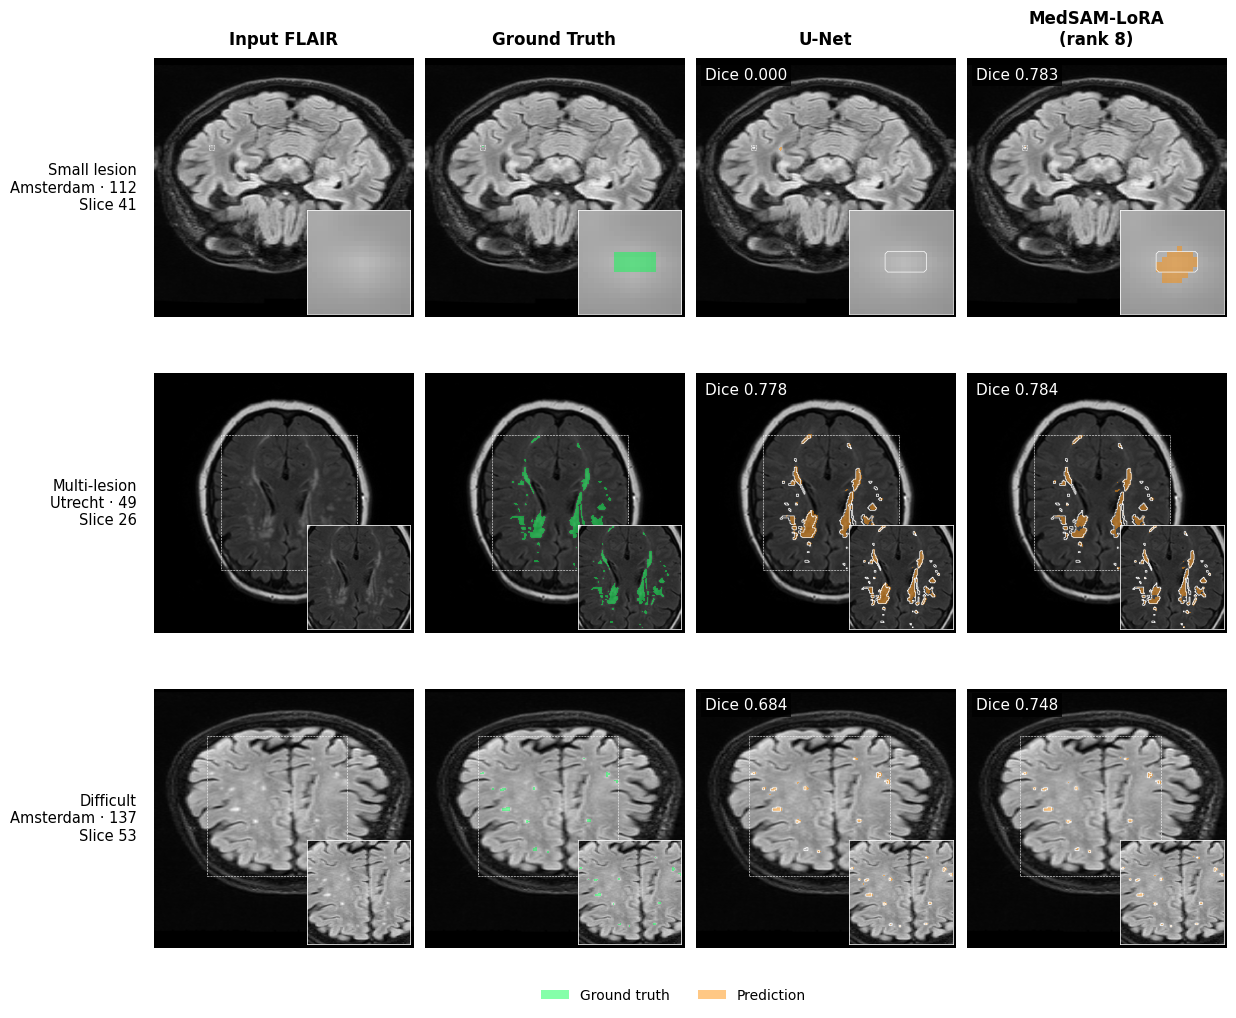

Saved main figure:
/content/drive/MyDrive/WMH_MedSAM_Project/results/qualitative/main_figure_v1/main_qualitative_figure.png
/content/drive/MyDrive/WMH_MedSAM_Project/results/qualitative/main_figure_v1/main_qualitative_figure.pdf


In [18]:
# MODIFIED: 3x4 presentation only. Overlay/ROI helpers below are copied unchanged.
# Predictions, metrics_df, cases and provenance are supplied by the original pipeline.
plt.rcParams.update({'font.family':'DejaVu Sans', 'font.size':11,
                     'axes.titlesize':12, 'pdf.fonttype':42, 'ps.fonttype':42,
                     'savefig.facecolor':'white'})
MAIN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
figure_paths = []


def displayed(a):
    return np.asarray(a).T

def segmentation_panel(
    ax,
    image,
    seg=None,
    gt_outline=None,
    seg_color=PRED_COLOR
):

    ax.imshow(
        displayed(image),
        cmap='gray',
        vmin=0,
        vmax=1,
        origin='lower',
        interpolation='nearest'
    )

    if seg is not None:

        overlay=np.zeros(
            (*seg.shape,4),
            dtype=np.float32
        )

        overlay[:,:,:3]=to_rgb(seg_color)
        overlay[:,:,3]=np.asarray(seg)*OVERLAY_ALPHA

        ax.imshow(
            overlay.transpose(1,0,2),
            origin='lower',
            interpolation='nearest'
        )

    if gt_outline is not None and gt_outline.any() and not gt_outline.all():

        ax.contour(
            displayed(gt_outline).astype(float),
            levels=[.5],
            colors='white',
            linewidths=.5
        )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

def shared_roi(target):

    if not SHOW_SHARED_INSETS or not target.any():
        return None

    yy,xx=np.where(displayed(target))

    side=max(
        INSET_MIN_SIZE,
        int(max(xx.max()-xx.min()+1,
                yy.max()-yy.min()+1))
        +2*INSET_PADDING
    )

    if side>int(.6*min(target.shape)):
        return None

    cx,cy=(xx.min()+xx.max())/2,(yy.min()+yy.max())/2

    x0=int(np.clip(
        round(cx-side/2),
        0,
        target.shape[0]-side
    ))

    y0=int(np.clip(
        round(cy-side/2),
        0,
        target.shape[1]-side
    ))

    return x0,y0,side

def add_shared_inset(ax,image,seg,outline,roi,seg_color=PRED_COLOR):

    if roi is None:
        return

    x0,y0,side=roi

    inset=ax.inset_axes(
        [.59,.015,.40,.40]
    )

    segmentation_panel(
        inset,
        image,
        seg,
        outline,
        seg_color=seg_color
    )

    inset.set_xlim(
        x0-.5,
        x0+side-.5
    )

    inset.set_ylim(
        y0-.5,
        y0+side-.5
    )

    for spine in inset.spines.values():

        spine.set_visible(True)
        spine.set_edgecolor('white')
        spine.set_linewidth(.55)

    ax.add_patch(
        Rectangle(
            (x0-.5,y0-.5),
            side,
            side,
            fill=False,
            edgecolor='white',
            linewidth=.4,
            linestyle='--'
        )
    )

lookup = metrics_df.set_index(['model'] + KEYS)

def render_main_figure(frame):
    assert len(frame) == 3
    fig, axes = plt.subplots(3, 4, figsize=(13, 10.55), squeeze=False)
    titles = ['Input FLAIR', 'Ground Truth', 'U-Net', f'MedSAM-LoRA\n(rank {BEST_LORA_RANK})']
    for col, title in enumerate(titles):
        axes[0, col].set_title(title, fontsize=12, fontweight='bold', pad=10)
    for ri, case in enumerate(frame.itertuples(index=False)):
        key = (case.site, case.patient_id, int(case.slice_id))
        image, target = cases[key]['image'], cases[key]['target']
        segmentation_panel(axes[ri, 0], image)
        segmentation_panel(axes[ri, 1], image, target, seg_color=GT_COLOR)
        roi = shared_roi(target)
        add_shared_inset(axes[ri, 0], image, None, None, roi)
        add_shared_inset(axes[ri, 1], image, target, None, roi, seg_color=GT_COLOR)
        axes[ri, 0].set_ylabel(
            f'{case.category}\n{case.site} · {case.patient_id}\nSlice {case.slice_id}',
            fontsize=10.5, rotation=0, ha='right', va='center', labelpad=12)
        for col, model_name in enumerate(MAIN_MODELS, start=2):
            ax = axes[ri, col]
            segmentation_panel(ax, image, predictions[(model_name, key)], target, seg_color=PRED_COLOR)
            add_shared_inset(ax, image, predictions[(model_name, key)], target, roi, seg_color=PRED_COLOR)
            dice = float(lookup.loc[(model_name, *key), 'dice'])
            ax.text(.035, .965, f'Dice {dice:.3f}', transform=ax.transAxes,
                    ha='left', va='top', fontsize=11, color='white',
                    bbox={'facecolor':'black', 'alpha':.78, 'edgecolor':'none', 'pad':3})
    fig.legend(handles=[Patch(facecolor=GT_COLOR, alpha=OVERLAY_ALPHA, label='Ground truth'),
                        Patch(facecolor=PRED_COLOR, alpha=OVERLAY_ALPHA, label='Prediction')],
               loc='lower center', bbox_to_anchor=(.57, .01), ncol=2, frameon=False, fontsize=10)
    fig.subplots_adjust(left=.17, right=.995, top=1-.70/10.55, bottom=.60/10.55,
                        wspace=.045, hspace=.07)
    for extension in ['png', 'pdf']:
        path = MAIN_OUTPUT_DIR / f'main_qualitative_figure.{extension}'
        fig.savefig(path, dpi=DPI, bbox_inches='tight', pad_inches=.15)
        figure_paths.append(path)
    return fig

fig = render_main_figure(main_selected)
plt.show()
plt.close(fig)
print('Saved main figure:', *figure_paths, sep='\n')


### 15. Main caption and unchanged inherited pipeline provenance


In [19]:
# MODIFIED: main-figure caption only; provenance computations below remain unchanged.
caption=(
 f'Qualitative WMH segmentation for three existing supplementary cases. Columns: input FLAIR, ground truth, U-Net, MedSAM-LoRA rank {BEST_LORA_RANK}. '
 'Green overlays indicate GT; orange overlays indicate predictions, with white GT contours in prediction panels. '
 'Per-panel Dice is the unchanged full-slice 1024x1024 binary metric, never a crop score. '
 'Existing GT-derived zoom regions and display orientation are applied identically to all four panels. '
 'Small lesion, Multi-lesion and Difficult are existing supplementary labels; they are not selected by model performance. '
 f'The displayed LoRA rank is selected from already recorded overall test Dice under {RANKING_PROTOCOL}, not from these case scores. '
 'This post hoc display choice is not an independent test-set model-selection result. '
 'MedSAM uses GT-derived box prompts, whereas U-Net is image-only. '
 'Frozen MedSAM comparisons remain in the supplementary figure and quantitative analysis. '
 'No superiority on every case or clinical severity interpretation is implied.'
)
if MANUAL_CASES is not None:caption+=' Case selection was manually overridden; see selected_cases.csv for reasons.'
if metrics_df.provenance_status.eq('legacy provenance unverified').any():
    caption+=' Some reused predictions lack original checkpoint/input fingerprints; see provenance_status before publication.'
(OUTPUT_DIR/'figure_caption.txt').write_text(caption+'\n')
for path,expected in tracked_inputs.items():
    assert sha256_file(path)==expected,f'Input changed during this run: {path}'
config={'project_root':str(PROJECT_ROOT),'output_dir':str(OUTPUT_DIR),'test_csv':str(TEST_CSV_PATH),
        'checkpoints':{k:str(v) for k,v in chosen_checkpoints.items()},
        'manifests':[str(p) for p in manifests],'manual_cases':MANUAL_CASES,'model_aliases':MODEL_ALIASES,
        'require_verified_predictions':REQUIRE_VERIFIED_PREDICTIONS,'seed':SEED,'threshold':THRESHOLD,
        'score_size':SCORE_SIZE,'dpi':DPI,'mask_color':MASK_COLOR,'overlay_alpha':OVERLAY_ALPHA,
        'shared_insets':SHOW_SHARED_INSETS,'inset_min_size':INSET_MIN_SIZE,'inset_padding':INSET_PADDING}
(OUTPUT_DIR/'figure_config.json').write_text(json.dumps(config,indent=2))
provenance={'training_performed':False,'input_files_sha256':tracked_inputs,
 'architecture':architecture_provenance,'python':sys.version,'platform':platform.platform(),
 'torch':str(torch.__version__),'cuda':torch.version.cuda,'numpy':np.__version__,
 'matplotlib':matplotlib.__version__,'device':str(device),
 'gpu':torch.cuda.get_device_name() if device.type=='cuda' else None,
 'cuda_matmul_allow_tf32':torch.backends.cuda.matmul.allow_tf32,
 'cudnn_allow_tf32':torch.backends.cudnn.allow_tf32,
 'test_slices':537,'selected_cases':5,'selected_predictions':20,
 'selection':'manual with recorded reasons' if MANUAL_CASES is not None else 'GT-only deterministic morphology',
 'case_metrics':'binary target>0; per-slice epsilon=1e-7; no batch aggregation',
 'prediction_provenance':metrics_df[['category']+KEYS+['model','source_type','source_path','checkpoint_sha256','provenance_status']].to_dict('records'),
 'figures_sha256':{p.name:sha256_file(p) for p in figure_paths}}
(OUTPUT_DIR/'figure_provenance.json').write_text(json.dumps(provenance,indent=2))
(OUTPUT_DIR/'requirements_observed.txt').write_text(subprocess.check_output([sys.executable,'-m','pip','freeze'],text=True))
print('Completed. Existing inputs unchanged. Figures and selected-case tables:',OUTPUT_DIR)


Completed. Existing inputs unchanged. Figures and selected-case tables: /content/drive/MyDrive/WMH_MedSAM_Project/results/qualitative/main_figure_v1/pipeline_audit


### 16. Added — save selected cases and the main provenance wrapper


In [20]:
# ADDED: main-paper exports wrap, rather than replace, the inherited pipeline provenance.
main_rows = []
for case in main_selected.to_dict('records'):
    key = (case['site'], case['patient_id'], int(case['slice_id']))
    main_rows.append({**case,
        'displayed_lora_model': BEST_LORA_MODEL, 'displayed_lora_rank': BEST_LORA_RANK,
        'unet_dice': float(lookup.loc[('unet', *key), 'dice']),
        'medsam_lora_dice': float(lookup.loc[(BEST_LORA_MODEL, *key), 'dice']),
        'supplementary_cases_csv': str(supplementary_case_path)})
main_case_csv = MAIN_OUTPUT_DIR / 'selected_cases.csv'
pd.DataFrame(main_rows).to_csv(main_case_csv, index=False)
main_provenance = {
    'artifact': 'main_paper_qualitative_figure', 'training_performed': False,
    'source_notebook': 'WMH_Qualitative_Segmentation_Figures_FINAL.ipynb',
    'source_notebook_sha256': SOURCE_SUPPLEMENTARY_SHA256,
    'main_cases': 3, 'main_predictions': 6, 'main_models': MAIN_MODELS,
    'displayed_lora_rank': BEST_LORA_RANK,
    'rank_selection': {'metric':'recorded overall Dice', 'protocol':RANKING_PROTOCOL,
                       'evidence':rank_evidence, 'tie_break':'rank 4 only on an exact recorded-score tie',
                       'selection_scope':'post hoc display choice using existing test results'},
    'case_selection': {'categories':MAIN_CATEGORIES, 'cases':main_rows,
                       'source_path':str(supplementary_case_path),
                       'source_sha256':tracked_inputs[str(supplementary_case_path)],
                       'site_coverage':main_selected.site.drop_duplicates().tolist(),
                       'rule':'exact category subset of existing validated supplementary cases; no performance-based substitution'},
    'main_prediction_audit':main_prediction_audit,
    'visualization': {'dpi':DPI, 'ground_truth_color':GT_COLOR, 'prediction_color':PRED_COLOR,
                      'overlay_alpha':OVERLAY_ALPHA, 'shared_insets':SHOW_SHARED_INSETS,
                      'inset_min_size':INSET_MIN_SIZE, 'inset_padding':INSET_PADDING,
                      'metric_annotation':'Dice on prediction panels only'},
    'caption':caption,
    'input_files_sha256':tracked_inputs,
    'pipeline_provenance_path':str(OUTPUT_DIR/'figure_provenance.json'),
    'pipeline_provenance_sha256':sha256_file(OUTPUT_DIR/'figure_provenance.json'),
    'pipeline_provenance':provenance,
    'output_sha256':{**{p.name:sha256_file(p) for p in figure_paths},
                     main_case_csv.name:sha256_file(main_case_csv)},
}
# Same read-only input verification as the inherited pipeline, after all main exports.
for path, expected in tracked_inputs.items():
    assert sha256_file(path) == expected, f'Input changed: {path}'
for record in main_prediction_audit:
    assert sha256_file(record['source_path']) == record['source_sha256']
(MAIN_OUTPUT_DIR/'provenance.json').write_text(json.dumps(main_provenance, indent=2))
print('Main-paper outputs:', MAIN_OUTPUT_DIR)
for name in ['main_qualitative_figure.png','main_qualitative_figure.pdf','selected_cases.csv','provenance.json']:
    print(MAIN_OUTPUT_DIR/name)


Main-paper outputs: /content/drive/MyDrive/WMH_MedSAM_Project/results/qualitative/main_figure_v1
/content/drive/MyDrive/WMH_MedSAM_Project/results/qualitative/main_figure_v1/main_qualitative_figure.png
/content/drive/MyDrive/WMH_MedSAM_Project/results/qualitative/main_figure_v1/main_qualitative_figure.pdf
/content/drive/MyDrive/WMH_MedSAM_Project/results/qualitative/main_figure_v1/selected_cases.csv
/content/drive/MyDrive/WMH_MedSAM_Project/results/qualitative/main_figure_v1/provenance.json


## Completion checks

The four requested main-paper files are saved at `results/qualitative/main_figure_v1/`.
The `pipeline_audit/` subdirectory retains the original five-case/four-model audit,
CSV and provenance outputs. Only the main plot/CSV contains the three-case subset.

Inspect the three-row PNG/PDF before submission. Any apparent improvement or
failure reflects the original predictions and Dice values. Keep the separate
quantitative and frozen-model evidence with the paper. This notebook is delivered
without execution outputs; source-preservation and synthetic rendering checks do
not constitute a real-data inference rerun or a measured ablation winner.
